# Training Insight Charts

Generation-aware Plotly views for NEAT deck-builder and evaluator analysis.

Important terminology used throughout this notebook:

- `outer_gen` is the deck-builder generation. Each deck-builder genome creates a deck, and that deck is evaluated against other generated decks.
- `inner_gen` is the player-controller/evaluator generation. For a fixed pair of decks, NEAT trains controllers that learn how to pilot those decks.
- Generation groups split outer generations into early/mid/late buckets so early weak decks do not get mixed with late stronger decks.

These charts analyze deck composition and matchup logs. They do not claim true drawn-card or played-card win rates, because those events are not persisted by the current game loop.

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().resolve()
while project_root.name != "Draci_zvesti_merged" and project_root.parent != project_root:
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from neat_ai.analysis.insight_charts import (
    plot_outer_fitness_distribution,
    plot_card_meta_timeline,
    plot_card_pair_synergy_timeline,
    plot_deck_archetype_learning_curves,
    plot_matchup_heatmaps_by_generation_group,
)

project_root

PosixPath('/home/electro/Personal/UPOL/Draci_zvesti_merged')

## 1. Outer Deck-Builder Fitness

This graph answers: is the deck-builder producing better decks over outer generations?

Each point is one logged deck-builder genome/deck. The y-axis is final deck-builder fitness after evaluation. The x-axis is `outer_gen`. The box summarizes the generation: median, spread, and outliers.

How to read it:

- Rising median means the average generated deck is improving.
- Rising maximum with flat median means training finds occasional strong decks, but the whole population is not consistently better.
- Wide boxes mean a generation has very uneven deck quality.
- Late outliers are good deck candidates, but they do not prove the whole meta improved.

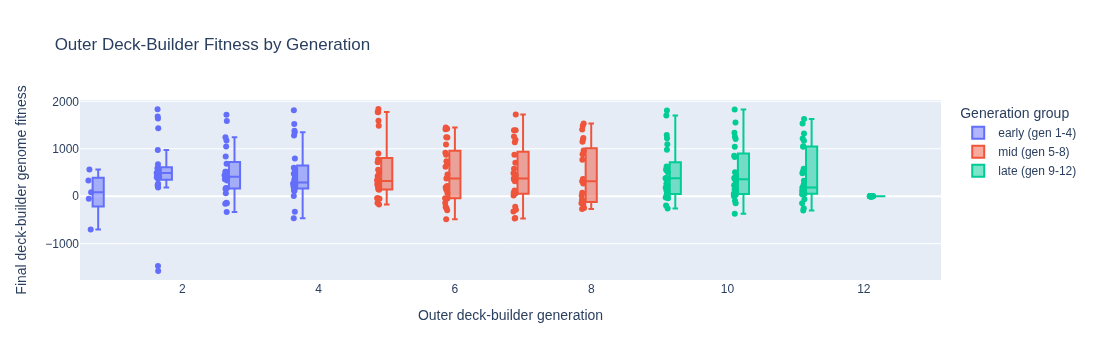

In [2]:
plot_outer_fitness_distribution(group_count=3).show()

## 2. Card Meta Timeline

This graph answers: which cards are strong or popular in early, mid, and late deck-builder generations?

Rows are cards. Columns are generation groups. Color is the selected metric. Useful metrics are `average_score`, `pick_rate`, `copy_rate`, and `average_copies`.

How to read it:

- A card bright only in early generations may be a simple/exploration card that gets replaced later.
- A card bright only in late generations may need better supporting cards or better deck-builder behavior before it becomes useful.
- High `pick_rate` but low `average_score` means the AI selects the card often but those decks are not especially successful.
- High `average_score` but low `pick_rate` marks a possible underexplored strong card.

Limitation: this is card presence in generated decks, not true drawn/played win rate.

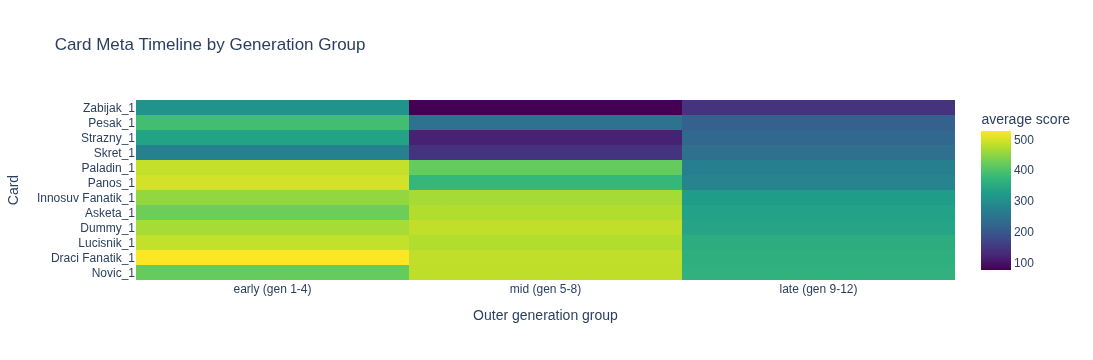

In [3]:
plot_card_meta_timeline(metric="average_score", group_count=3).show()

## 3. Card Pair Synergy Timeline

This graph answers: which two-card combinations lift deck fitness inside their own generation group?

The metric is `lift`: average fitness of decks containing both cards minus the baseline average fitness of all decks in that same generation group.

How to read it:

- Positive lift means decks with the pair outperform the generation baseline.
- A pair that appears only in late generations may be an advanced synergy that was not discovered early.
- Low appearances make a pair less reliable, even if lift is high.
- This is stronger than simple co-occurrence because it compares against same-generation deck quality.

Limitation: it detects deck-building synergy, not a guaranteed in-game board interaction.

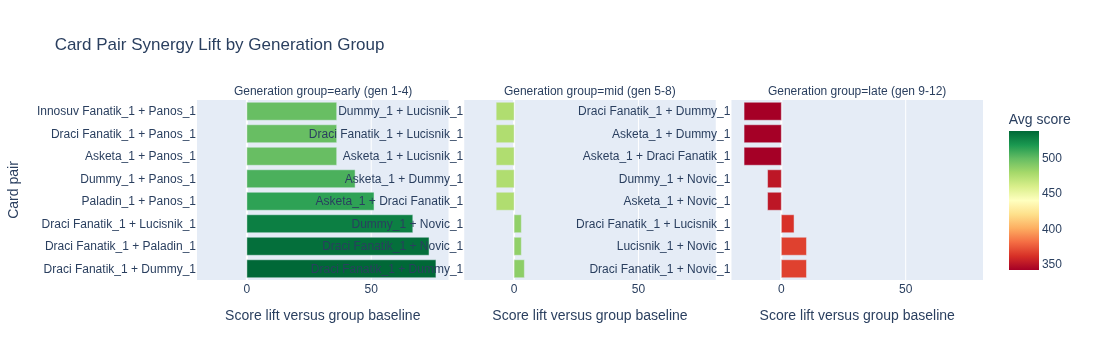

In [4]:
plot_card_pair_synergy_timeline(group_count=3, top_n_per_group=8, min_appearances=2).show()

## 4. High-Skill Deck Archetype Learning Curves

This graph answers: which decks become much better when the player-controller has time to learn them?

Each line is a selected deck archetype. The x-axis is `inner_gen`, the evaluator/controller generation. The y-axis is the deck-perspective average controller score. Facets separate outer generation groups.

How to read it:

- High starting score means the deck is easy to pilot.
- Steep upward slope means the deck has high skill ceiling.
- Flat but high lines are reliable/simple archetypes.
- Low but rising lines may be promising but undertrained.
- Compare lines inside the same facet first; cross-facet comparisons mix different outer-generation metas.

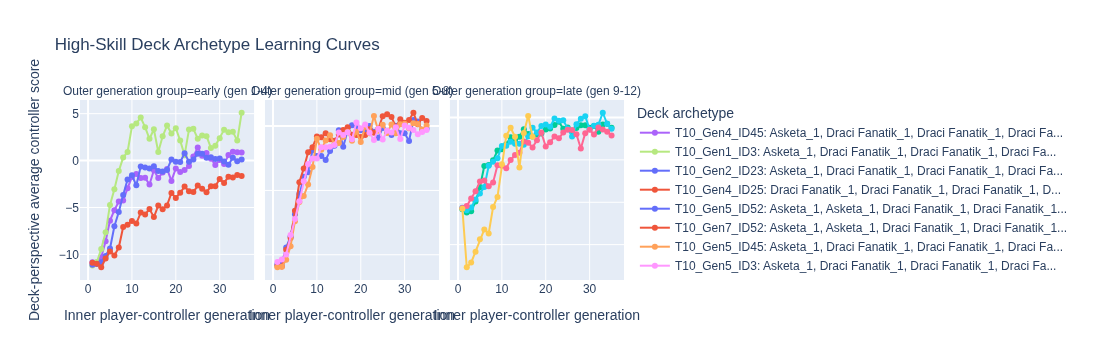

In [5]:
plot_deck_archetype_learning_curves(group_count=3, top_n_per_group=4, min_samples=100).show()

## 5. Generation-Sliced Matchup Heatmaps

This graph answers: which top decks beat which other top decks within the same generation group?

Rows are decks being evaluated. Columns are opponents. A positive cell favors the row deck; a negative cell favors the column deck. Each facet is a separate outer-generation group.

How to read it:

- Green row segments show decks that beat many local top decks.
- Red row segments show weak or countered decks.
- Mixed rows indicate polarized decks: strong into some opponents, weak into others.
- A deck can dominate early and disappear later, so generation-sliced heatmaps are safer than one global matrix.

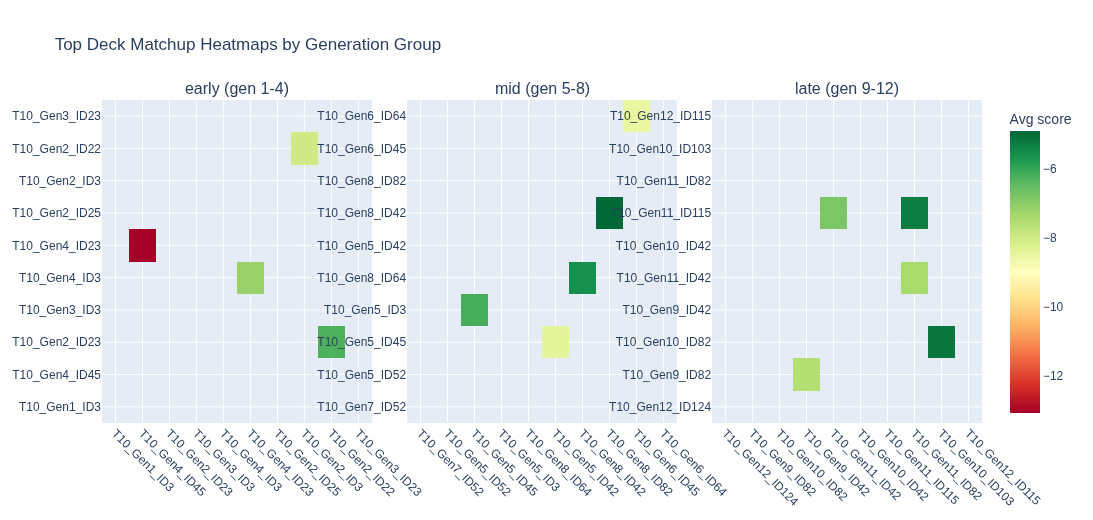

In [6]:
plot_matchup_heatmaps_by_generation_group(group_count=3, top_decks_per_group=10).show()